In [45]:
import numpy as np
import pyccl as ccl
import math

from astropy import units as u
from astropy.cosmology import FlatLambdaCDM
from astropy.table import vstack, Table
from scipy.interpolate import interp1d

import sys
project_root ="/global/cfs/projectdirs/desi/users/qlavier/desi-y3-hsc/"
if project_root not in sys.path:
    sys.path.insert(0, project_root)
import src.statistics.corrfiles as cf

# Define the cosmology model and global constants.

# parameters
# We use: ΩDM = 0.258868, Ωb = 0.048252, ℎ = 0.6777, 𝑛𝑠 = 0.95 and 𝜎8 = 0.8
# (from HSC WL-photoz tomographic analysis, see https://arxiv.org/pdf/2211.16516)
omega_c = 0.258868
omega_b = 0.048252
omega_m = omega_c + omega_b
h = 0.6777
H0 = h * 100
sigma8 = 0.8
n_s = 0.95

# from Core Cosmology Library (CCL)
COSMO_ccl = ccl.Cosmology(Omega_c=omega_c, Omega_b=omega_b, h=h, sigma8=sigma8, n_s=n_s)
# from astropy.cosmology
COSMO_astropy = FlatLambdaCDM(
    H0=H0,
    Om0=omega_m,
    Ob0=omega_b,
)

def arcsec2hMpc(theta, z):
    """
    Convert angular separation (in arcseconds) to
    transverse comoving separation (in h^-1 Mpc).

    Parameters:
    theta: float
       Angular separation in arcseconds
    z: float
       Redshift
    """
    theta = theta * u.arcsec
    d_pm = COSMO_astropy.comoving_transverse_distance(z)
    x = (theta * d_pm).to(u.Mpc, u.dimensionless_angles())
    x *= COSMO_astropy.h
    return x.value

arcsec2hMpc(360, 0.6)

2.6878713278194772

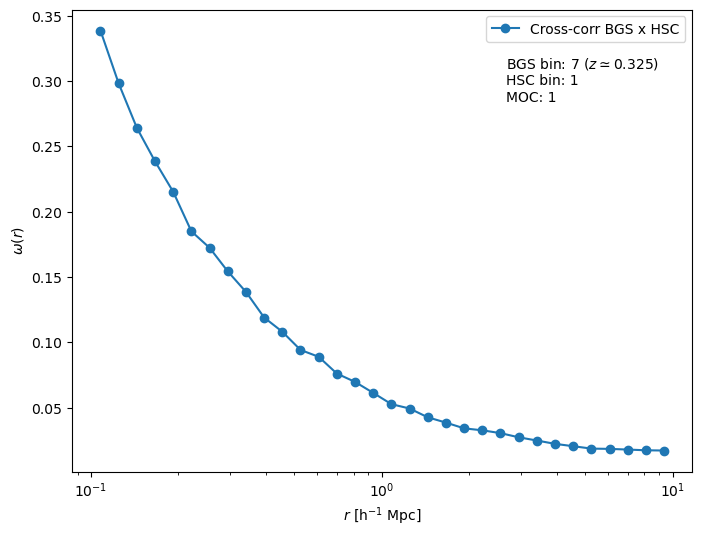

In [41]:
import numpy as np
import matplotlib.pyplot as plt

bin_BGS = 7 # from 1 to 12
bin_HSC = 1 # from 1 to 4
moc = 1     # from 1 to 4

bgs_edges = np.arange(0, 0.65, 0.05)
def get_bgs_redshift(i, j, moc_k):
    z_min = bgs_edges[i-1]
    z_max = bgs_edges[i]
    return (z_min + z_max) / 2

# Exemple d'utilisation pour b1x7_b2x1_moc1
redshift = get_bgs_redshift(i=bin_BGS, j=bin_HSC, moc_k=moc)

path = f'outputs/dr2/cross/BGS_ANYxHSC/BGS_ANYxHSC_b1x{bin_BGS}_b2x{bin_HSC}_moc{moc}.npy'
bin_bgs = path.split('b1x')[-1].split('_b2x')[0]  # Extrait "BGS_ANYxHSC"
bin_hsc = path.split('b2x')[-1].split('_moc')[0]  # Extrait "BGS_ANYxHSC"

# 1. Charger le fichier
data = np.load(path, allow_pickle=True)

# 2. Extraire l'objet (Correction de l'IndexError)
res = data.item() 

# Si 'res' est une liste (ce qui arrive parfois selon comment pycorr a sauvé), 
# on prend le premier élément :
if isinstance(res, list):
    res = res[0]

# 3. Maintenant tu peux inspecter les clés
#print("Clés disponibles :", res.keys())

# Pour accéder aux données Davis-Peebles par exemple :
# print(res['davispeebles']['D1D2']['wcounts'])

# Extraction
theta = res['D1D2']['seps'][0]
d1d2 = res['D1D2']['wcounts']
norm_d1d2 = res['D1D2']['wnorm']
d1r2 = res['D1R2']['wcounts']
norm_d1r2 = res['D1R2']['wnorm']
rp = arcsec2hMpc(theta*3600, redshift)
# Calcul de la corrélation w(theta)
w = (d1d2 / norm_d1d2) / (d1r2 / norm_d1r2) - 1

# Sauvegarde en fichier texte lisible
output = np.column_stack((theta, w))
#np.savetxt('correlation_lisible.txt', output, header='Theta(deg)  w(theta)', fmt='%.6e')

#print("Fichier 'correlation_lisible.txt' créé ! Tu peux l'ouvrir avec VS Code.")

plt.figure(figsize=(8, 6))
plt.plot(rp, w, 'o-', label='Cross-corr BGS x HSC')
plt.xscale('log')
#plt.yscale('log')
plt.xlabel(r'$r$ [h$^{-1}$ Mpc]')
plt.ylabel(r'$\omega(r)$')
plt.legend()
text = fr'BGS bin: {bin_bgs} ($z \simeq {redshift:.3f}$)' f'\nHSC bin: {bin_hsc}\nMOC: {moc}'
plt.text(0.7, 0.9, text, transform=plt.gca().transAxes, verticalalignment='top')

plt.show()